# Midterm

### Task 1: Verify your Google Cloud environment setup, including capturing proof of your active cloud notebook instance or billing credit balance.

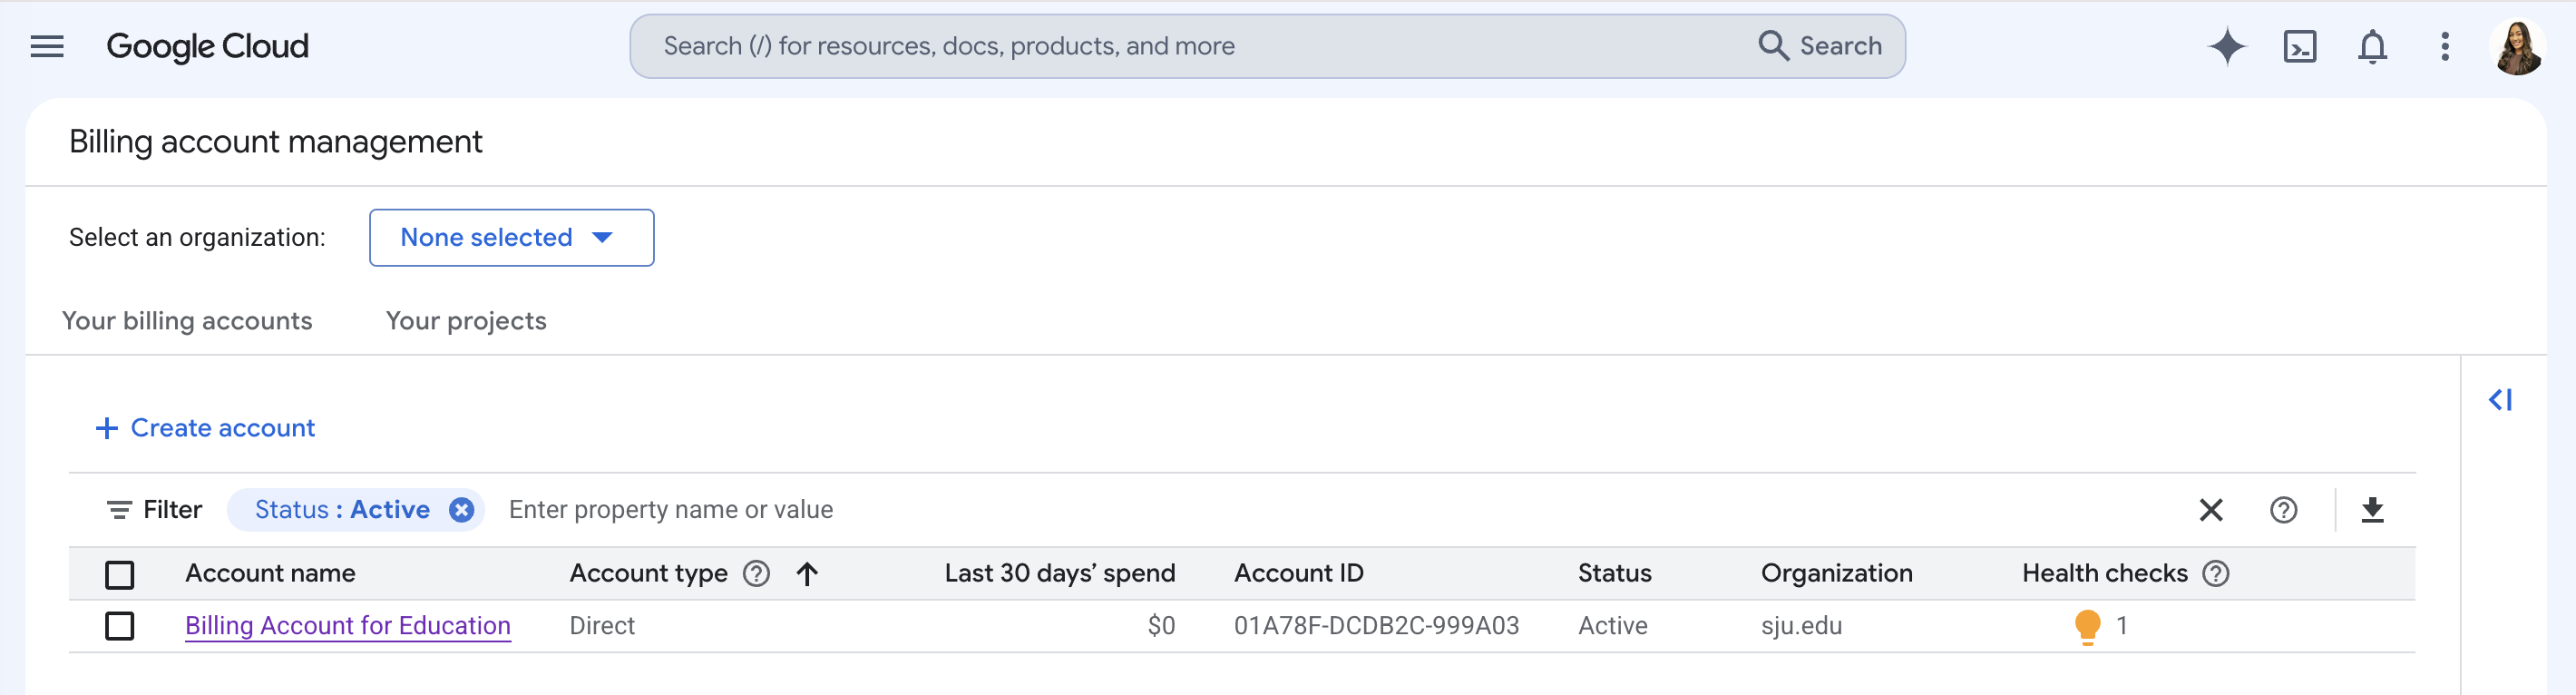

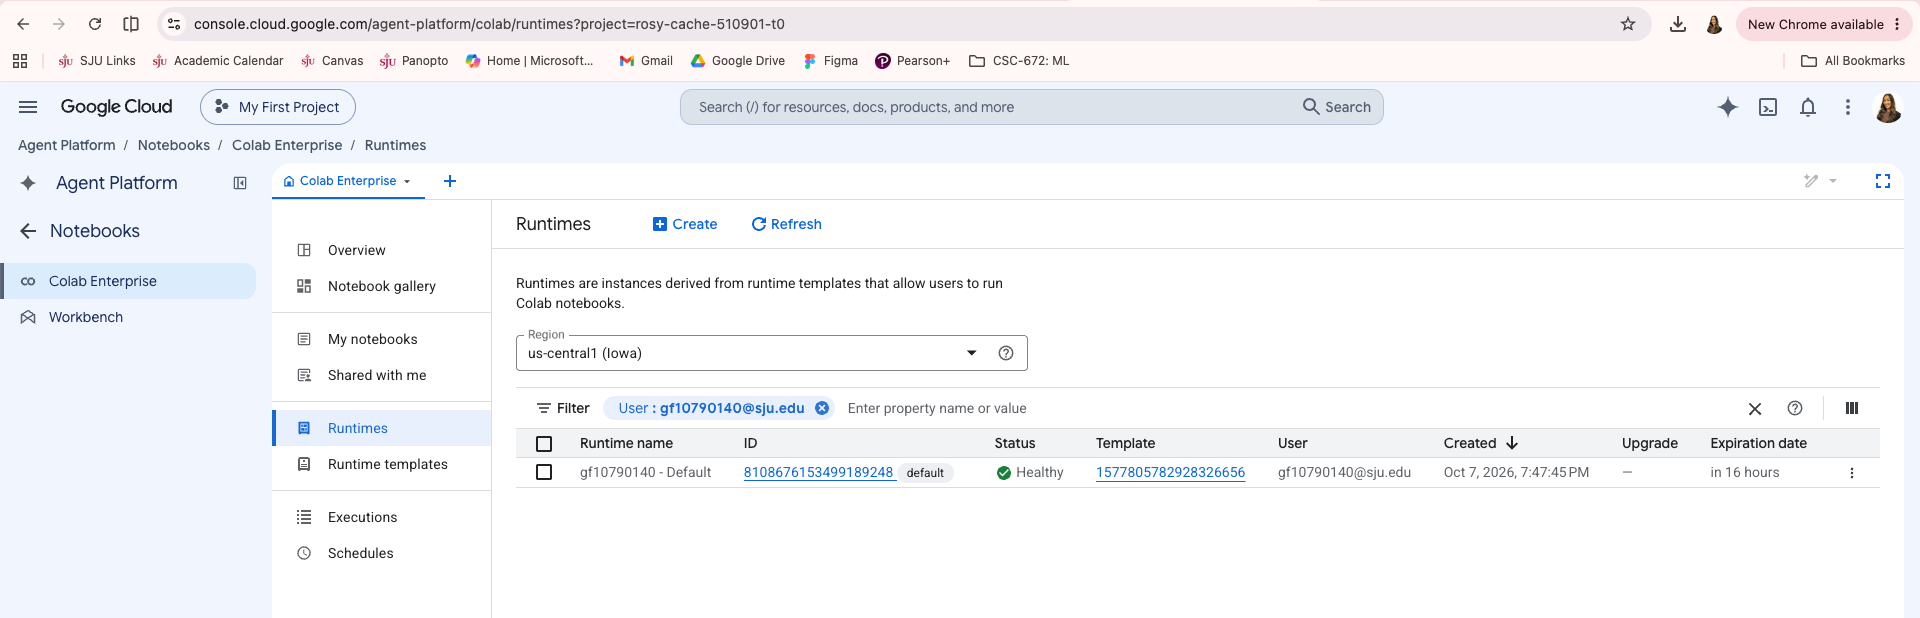

In [118]:
import platform, os, datetime, requests, socket

def meta(path):
    r = requests.get(f"http://metadata.google.internal/computeMetadata/v1/{path}",
                     headers={"Metadata-Flavor": "Google"}, timeout=3)
    return r.text if r.status_code == 200 else f"unavailable (HTTP {r.status_code})"

for label, path in [("Project ID", "project/project-id"),
                    ("Project number", "project/numeric-project-id"),
                    ("Service account", "instance/service-accounts/default/email"),
                    ("Region/zone", "instance/zone"),
                    ("Machine type", "instance/machine-type")]:
    try:
        print(f"{label}: {meta(path)}")
    except Exception as e:
        print(f"{label}: unavailable ({type(e).__name__})")

print("Hostname:", socket.gethostname())
print("Platform:", platform.platform())
print("CPU count:", os.cpu_count())
print("Memory (GB):", round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 1e9, 1))
print("Timestamp:", datetime.datetime.now().isoformat())

Project ID: rosy-cache-510901-t0
Project number: 406790307592
Service account: gf10790140@sju.edu
Region/zone: unavailable (HTTP 404)
Machine type: unavailable (HTTP 404)
Hostname: 6c7b212926e8
Platform: Linux-6.6.153+-x86_64-with-glibc2.35
CPU count: 4
Memory (GB): 16.8
Timestamp: 2026-10-08T01:03:54.151116


###Task 2: Load the dataset into a Pandas DataFrame using the official ucimlrepo package or direct data retrieval methods linked to the UCI repository (https://archive.ics.uci.edu/dataset/360/air+qualityLinks to an external site.).

In [119]:
%pip install ucimlrepo

In [120]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

air_quality = fetch_ucirepo(id=360)
df = air_quality.data.original
print(df.shape)

(9357, 15)


### Task 3: Use structural inspection methods (head(), info(), describe()) to analyze the dataset structure and examine feature distributions across sensor and meteorological variables.

In [121]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [123]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


Sentinel (-200) counts per column:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64 

--- Metal-oxide sensor responses ---
       PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)
count      8991.00        8991.00       8991.00       8991.00      8991.00
mean       1099.83         939.15        835.49       1456.26      1022.91
std         217.08         266.83        256.82        346.21       398.48
min         647.00         383.00        322.00        551.00       221.00
25%         937.00         734.50        658.00       1227.00       731.50
50%        1063.00         909.00        806.00       1463.00       963.00
75%        1231.00        1116.00        969.50       1674

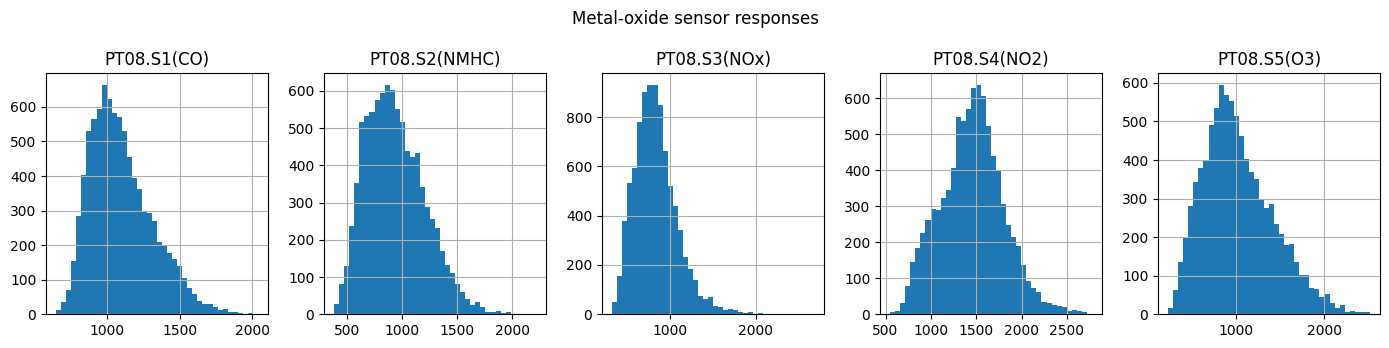

--- Reference gas analyzers ---
        CO(GT)  NMHC(GT)  C6H6(GT)  NOx(GT)  NO2(GT)
count  7674.00    914.00   8991.00  7718.00  7715.00
mean      2.15    218.81     10.08   246.90   113.09
std       1.45    204.46      7.45   212.98    48.37
min       0.10      7.00      0.10     2.00     2.00
25%       1.10     67.00      4.40    98.00    78.00
50%       1.80    150.00      8.20   180.00   109.00
75%       2.90    297.00     14.00   326.00   142.00
max      11.90   1189.00     63.70  1479.00   340.00 



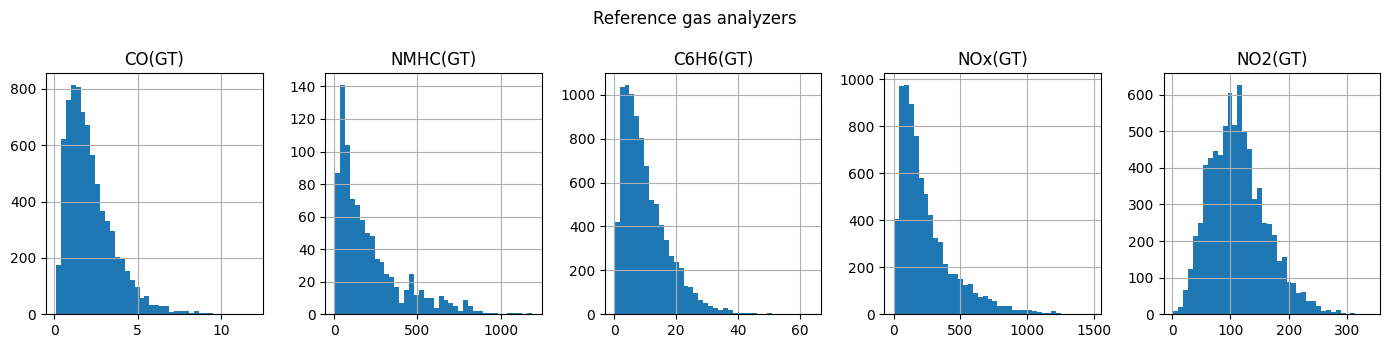

--- Meteorological variables ---
             T       RH       AH
count  8991.00  8991.00  8991.00
mean     18.32    49.23     1.03
std       8.83    17.32     0.40
min      -1.90     9.20     0.18
25%      11.80    35.80     0.74
50%      17.80    49.60     1.00
75%      24.40    62.50     1.31
max      44.60    88.70     2.23 



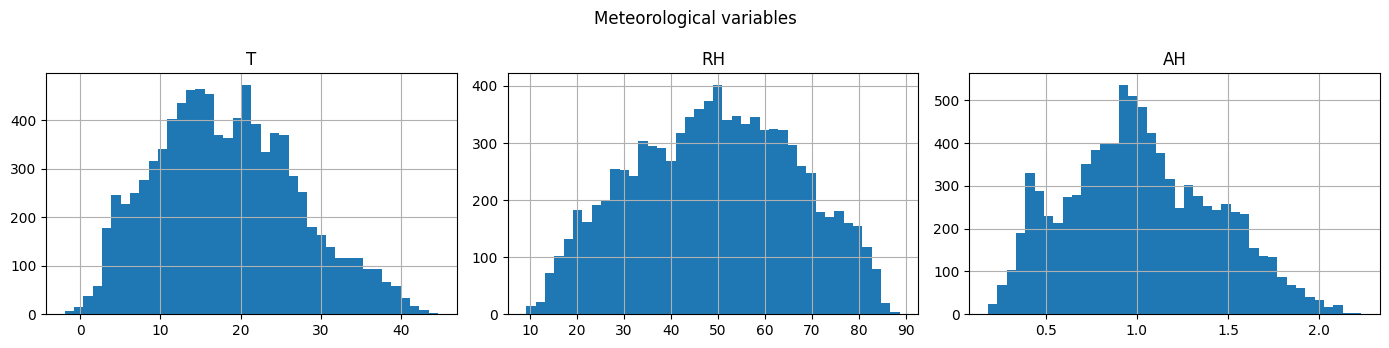

Skewness:
PT08.S1(CO)      0.76
PT08.S2(NMHC)    0.56
PT08.S3(NOx)     1.10
PT08.S4(NO2)     0.21
PT08.S5(O3)      0.63
CO(GT)           1.37
NMHC(GT)         1.56
C6H6(GT)         1.36
NOx(GT)          1.72
NO2(GT)          0.62
T                0.31
RH              -0.04
AH               0.25
dtype: float64


In [124]:
import matplotlib.pyplot as plt

sensor_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
reference_cols = ["CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
met_cols = ["T", "RH", "AH"]

# -200 is a missing-value marker, so exclude it to see the real distributions
df_view = df.replace(-200, np.nan)

print("Sentinel (-200) counts per column:")
print((df == -200).sum(), "\n")

for title, cols in [("Metal-oxide sensor responses", sensor_cols),
                    ("Reference gas analyzers", reference_cols),
                    ("Meteorological variables", met_cols)]:
    print(f"--- {title} ---")
    print(df_view[cols].describe().round(2), "\n")
    df_view[cols].hist(bins=40, figsize=(14, 3.5), layout=(1, len(cols)))
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Skewness:")
print(df_view[sensor_cols + reference_cols + met_cols].skew().round(2))

### Task 4: Identify and handle implicit missing data values (such as the standard -200 sentinel values present in the air quality dataset) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [125]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include="number").columns

sentinel_summary = pd.DataFrame({
    "count_-200": (df[num_cols] == -200).sum(),
    "percent": ((df[num_cols] == -200).mean() * 100).round(2),
}).sort_values("percent", ascending=False)
print(sentinel_summary)

               count_-200  percent
NMHC(GT)             8443    90.23
CO(GT)               1683    17.99
NO2(GT)              1642    17.55
NOx(GT)              1639    17.52
PT08.S1(CO)           366     3.91
PT08.S2(NMHC)         366     3.91
C6H6(GT)              366     3.91
PT08.S3(NOx)          366     3.91
PT08.S4(NO2)          366     3.91
PT08.S5(O3)           366     3.91
T                     366     3.91
RH                    366     3.91
AH                    366     3.91


In [126]:
df_nan = df.copy()
df_nan[num_cols] = df_nan[num_cols].replace(-200, np.nan)

print("Remaining -200 values:", (df_nan[num_cols] == -200).sum().sum())
print("\nNaN counts after conversion:")
print(df_nan[num_cols].isna().sum())

Remaining -200 values: 0

NaN counts after conversion:
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [127]:
threshold = 0.5
missing_frac = df_nan[num_cols].isna().mean().round(3)
print(missing_frac)

drop_cols = missing_frac[missing_frac > threshold].index.tolist()
print("\nDropping columns with >50% missing:", drop_cols)

df_nan = df_nan.drop(columns=drop_cols)
num_cols = df_nan.select_dtypes(include="number").columns

CO(GT)           0.180
PT08.S1(CO)      0.039
NMHC(GT)         0.902
C6H6(GT)         0.039
PT08.S2(NMHC)    0.039
NOx(GT)          0.175
PT08.S3(NOx)     0.039
NO2(GT)          0.175
PT08.S4(NO2)     0.039
PT08.S5(O3)      0.039
T                0.039
RH               0.039
AH               0.039
dtype: float64

Dropping columns with >50% missing: ['NMHC(GT)']


In [128]:
imputer = SimpleImputer(strategy="median")
imputed = pd.DataFrame(imputer.fit_transform(df_nan[num_cols]),
                       columns=num_cols, index=df_nan.index)

print("Medians used for imputation:")
print(pd.Series(imputer.statistics_, index=num_cols).round(3))
print("\nRemaining NaNs after imputation:", imputed.isna().sum().sum())

print("\nStd before vs. after imputation:")
print(pd.DataFrame({"before": df_nan[num_cols].std(), "after": imputed.std()}).round(3))

Medians used for imputation:
CO(GT)              1.800
PT08.S1(CO)      1063.000
C6H6(GT)            8.200
PT08.S2(NMHC)     909.000
NOx(GT)           180.000
PT08.S3(NOx)      806.000
NO2(GT)           109.000
PT08.S4(NO2)     1463.000
PT08.S5(O3)       963.000
T                  17.800
RH                 49.600
AH                  0.995
dtype: float64

Remaining NaNs after imputation: 0

Std before vs. after imputation:
                before    after
CO(GT)           1.453    1.323
PT08.S1(CO)    217.080  212.911
C6H6(GT)         7.450    7.312
PT08.S2(NMHC)  266.831  261.626
NOx(GT)        212.979  195.091
PT08.S3(NOx)   256.817  251.809
NO2(GT)         48.370   43.949
PT08.S4(NO2)   346.207  339.370
PT08.S5(O3)    398.484  390.785
T                8.832    8.658
RH              17.317   16.975
AH               0.404    0.396


### Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and necessary encoding to categorical/temporal features.

In [129]:
df_model = df_nan.copy()

t = df_model["Time"].astype(str).str.replace(".", ":", regex=False)
raw = df_model["Date"].astype(str) + " " + t
dt = pd.to_datetime(raw, dayfirst=False)
if not dt.is_monotonic_increasing:
    dt = pd.to_datetime(raw, dayfirst=True)
print("Date range:", dt.min(), "to", dt.max(), "| chronological:", dt.is_monotonic_increasing)

df_model["hour"] = dt.dt.hour
df_model["day_of_week"] = dt.dt.dayofweek
df_model["month"] = dt.dt.month
df_model = df_model.drop(columns=["Date", "Time"])

df_model[["hour", "day_of_week", "month"]].head()

Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00 | chronological: True


,hour,day_of_week,month
0,18,2,3
1,19,2,3
2,20,2,3
3,21,2,3
4,22,2,3


In [130]:
categorical_features = ["hour", "day_of_week", "month"]
numerical_features = [c for c in df_model.columns if c not in categorical_features]

print("Numerical features (%d):" % len(numerical_features))
print(numerical_features)
print("\nCategorical/temporal features (%d):" % len(categorical_features))
print(categorical_features)

print("\nUnique values per categorical feature:")
print(df_model[categorical_features].nunique())

Numerical features (12):
['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Categorical/temporal features (3):
['hour', 'day_of_week', 'month']

Unique values per categorical feature:
hour           24
day_of_week     7
month          12
dtype: int64


In [131]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_preprocessor(num_feats, cat_feats=categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, num_feats),
        ("cat", categorical_pipeline, cat_feats),
    ])

pipe = Pipeline([("preprocessor", build_preprocessor(numerical_features))])
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CO(GT)', 'PT08.S1(CO)',
                                                   'C6H6(GT)', 'PT08.S2(NMHC)',
                                                   'NOx(GT)', 'PT08.S3(NOx)',
                                                   'NO2(GT)', 'PT08.S4(NO2)',
                                                   'PT08.S5(O3)', 'T', 'RH',
                                                   'AH']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['hour', 'day_of_week',
                                                   'month'])]))])

In [132]:
X_out = pipe.fit_transform(df_model)
feat_names = pipe.named_steps["preprocessor"].get_feature_names_out()
X_out_df = pd.DataFrame(X_out, columns=feat_names)

print("Input shape: ", df_model.shape)
print("Output shape:", X_out_df.shape)
print("NaNs remaining:", int(X_out_df.isna().sum().sum()))

num_out = X_out_df[[f"num__{c}" for c in numerical_features]]
print("\nNumeric columns after StandardScaler:")
print(pd.DataFrame({"mean": num_out.mean(), "std": num_out.std()}).round(3))

print("\nEncoded columns: hour =", sum(c.startswith("cat__hour") for c in feat_names),
      "| day_of_week =", sum(c.startswith("cat__day_of_week") for c in feat_names),
      "| month =", sum(c.startswith("cat__month") for c in feat_names))

X_out_df.head()

Input shape:  (9357, 15)
Output shape: (9357, 55)
NaNs remaining: 0

Numeric columns after StandardScaler:
                    mean  std
num__CO(GT)          0.0  1.0
num__PT08.S1(CO)     0.0  1.0
num__C6H6(GT)        0.0  1.0
num__PT08.S2(NMHC)   0.0  1.0
num__NOx(GT)        -0.0  1.0
num__PT08.S3(NOx)   -0.0  1.0
num__NO2(GT)         0.0  1.0
num__PT08.S4(NO2)   -0.0  1.0
num__PT08.S5(O3)    -0.0  1.0
num__T               0.0  1.0
num__RH              0.0  1.0
num__AH              0.0  1.0

Encoded columns: hour = 24 | day_of_week = 7 | month = 12


,num__CO(GT),num__PT08.S1(CO),num__C6H6(GT),num__PT08.S2(NMHC),num__NOx(GT),num__PT08.S3(NOx),num__NO2(GT),num__PT08.S4(NO2),num__PT08.S5(O3),num__T,...,cat__month_3,cat__month_4,cat__month_5,cat__month_6,cat__month_7,cat__month_8,cat__month_9,cat__month_10,cat__month_11,cat__month_12
0,0.386029,1.228781,0.258577,0.412925,-0.354617,0.880318,0.014261,0.693887,0.633214,-0.542585,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.067502,0.909382,-0.083356,0.065082,-0.677560,1.348952,-0.463597,0.301964,-0.124277,-0.577236,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.083675,1.426057,-0.138065,0.003922,-0.534030,1.213922,0.037016,0.290176,0.136750,-0.738941,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.083675,1.303934,-0.110711,0.038324,-0.323861,1.023291,0.219057,0.375633,0.466873,-0.842894,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.369856,0.815441,-0.479998,-0.389791,-0.534030,1.472068,0.082526,0.098635,0.228878,-0.819793,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Task 6: Train classification models to predict air quality categories using standard logistic/softmax regression and an SGDClassifier configured with custom loss functions and hyperparameters, evaluating convergence speed and performance.

In [133]:
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

co = df["CO(GT)"].replace(-200, np.nan)
mask = co.notna()
y = pd.qcut(co[mask], q=3, labels=["Low", "Medium", "High"])

X = df_model.loc[mask].drop(columns=["CO(GT)"])
num_feats = [c for c in numerical_features if c != "CO(GT)"]

print(y.value_counts())
print("Class boundaries (CO mg/m3):", pd.qcut(co[mask], q=3).cat.categories.tolist())

CO(GT)
Low       2623
High      2545
Medium    2506
Name: count, dtype: int64
Class boundaries (CO mg/m3): [Interval(0.099, 1.3, closed='right'), Interval(1.3, 2.4, closed='right'), Interval(2.4, 11.9, closed='right')]


In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

prep = build_preprocessor(num_feats)
Xtr = prep.fit_transform(X_train)
Xte = prep.transform(X_test)
print("Train:", Xtr.shape, "| Test:", Xte.shape)

Train: (6139, 54) | Test: (1535, 54)


In [135]:
yb_train = (y_train == "High").astype(int)
yb_test = (y_test == "High").astype(int)

start = time.perf_counter()
logit = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr, yb_train)
logit_time = time.perf_counter() - start
pb = logit.predict(Xte)
print("Binary logistic (High vs rest)")
print("  iterations:", int(logit.n_iter_[0]), "| fit time:", round(logit_time, 4), "s")
print("  accuracy:", round(accuracy_score(yb_test, pb), 4),
      "| F1:", round(f1_score(yb_test, pb), 4))

start = time.perf_counter()
softmax = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr, y_train)
softmax_time = time.perf_counter() - start
ps = softmax.predict(Xte)
print("\nSoftmax regression (3 classes)")
print("  iterations:", int(softmax.n_iter_[0]), "| fit time:", round(softmax_time, 4), "s")
print("  accuracy:", round(accuracy_score(y_test, ps), 4),
      "| macro F1:", round(f1_score(y_test, ps, average="macro"), 4))

Binary logistic (High vs rest)
  iterations: 28 | fit time: 0.0327 s
  accuracy: 0.944 | F1: 0.9137

Softmax regression (3 classes)
  iterations: 77 | fit time: 2.0592 s
  accuracy: 0.8723 | macro F1: 0.8731


In [136]:
sgd_configs = {
    "log_loss, optimal lr": dict(loss="log_loss", learning_rate="optimal", alpha=1e-4),
    "hinge, optimal lr": dict(loss="hinge", learning_rate="optimal", alpha=1e-4),
    "modified_huber, optimal lr": dict(loss="modified_huber", learning_rate="optimal", alpha=1e-4),
    "log_loss, constant eta0=0.01": dict(loss="log_loss", learning_rate="constant", eta0=0.01, alpha=1e-4),
    "log_loss, constant eta0=0.0001": dict(loss="log_loss", learning_rate="constant", eta0=1e-4, alpha=1e-4),
    "log_loss, elasticnet": dict(loss="log_loss", learning_rate="optimal",
    penalty="elasticnet", alpha=1e-3, l1_ratio=0.15),
}

rows = [{
    "model": "Softmax (lbfgs)",
    "iterations": int(softmax.n_iter_[0]),
    "fit_time_s": round(softmax_time, 4),
    "train_acc": round(accuracy_score(y_train, softmax.predict(Xtr)), 4),
    "test_acc": round(accuracy_score(y_test, ps), 4),
    "macro_F1": round(f1_score(y_test, ps, average="macro"), 4),
}]

sgd_models = {}
for name, params in sgd_configs.items():
    clf = SGDClassifier(max_iter=1000, tol=1e-3, n_iter_no_change=5, random_state=42, **params)
    start = time.perf_counter()
    clf.fit(Xtr, y_train)
    elapsed = time.perf_counter() - start
    pred = clf.predict(Xte)
    sgd_models[name] = clf
    rows.append({
        "model": "SGD " + name,
        "iterations": int(clf.n_iter_),
        "fit_time_s": round(elapsed, 4),
        "train_acc": round(accuracy_score(y_train, clf.predict(Xtr)), 4),
        "test_acc": round(accuracy_score(y_test, pred), 4),
        "macro_F1": round(f1_score(y_test, pred, average="macro"), 4),
    })

results = pd.DataFrame(rows).set_index("model")
results

,iterations,fit_time_s,train_acc,test_acc,macro_F1
model,,,,,
Softmax (lbfgs),77,2.0592,0.8871,0.8723,0.8731
"SGD log_loss, optimal lr",46,0.3926,0.8674,0.8502,0.8522
"SGD hinge, optimal lr",46,0.1968,0.8628,0.8463,0.8485
"SGD modified_huber, optimal lr",78,0.3859,0.8303,0.8319,0.8276
"SGD log_loss, constant eta0=0.01",46,0.2493,0.8744,0.8619,0.8627
"SGD log_loss, constant eta0=0.0001",41,0.3489,0.8244,0.8235,0.8157
"SGD log_loss, elasticnet",15,0.1793,0.8786,0.8625,0.8623


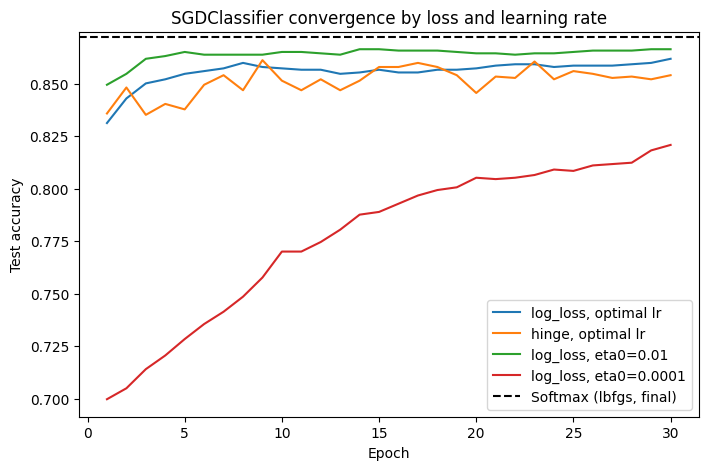

In [137]:
classes = np.array(["Low", "Medium", "High"])
curve_configs = {
    "log_loss, optimal lr":           dict(loss="log_loss", learning_rate="optimal", alpha=1e-4),
    "hinge, optimal lr":              dict(loss="hinge", learning_rate="optimal", alpha=1e-4),
    "log_loss, eta0=0.01":            dict(loss="log_loss", learning_rate="constant", eta0=0.01, alpha=1e-4),
    "log_loss, eta0=0.0001":          dict(loss="log_loss", learning_rate="constant", eta0=1e-4, alpha=1e-4),
}

n_epochs = 30
plt.figure(figsize=(8, 5))
for name, params in curve_configs.items():
    clf = SGDClassifier(random_state=42, **params)
    acc = []
    for _ in range(n_epochs):
        clf.partial_fit(Xtr, y_train, classes=classes)   # one pass over the training data
        acc.append(accuracy_score(y_test, clf.predict(Xte)))
    plt.plot(range(1, n_epochs + 1), acc, label=name)

plt.axhline(accuracy_score(y_test, ps), color="black", linestyle="--", label="Softmax (lbfgs, final)")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("SGDClassifier convergence by loss and learning rate")
plt.legend()
plt.show()

In [138]:
best_name = results.drop(index="Softmax (lbfgs)")["macro_F1"].idxmax()
best_sgd = sgd_models[best_name.replace("SGD ", "")]
print("Best SGD model by macro F1:", best_name)

for label, model in [("Softmax", softmax), (best_name, best_sgd)]:
    pred = model.predict(Xte)
    print(f"\n=== {label} ===")
    print(classification_report(y_test, pred, labels=classes))
    print(pd.DataFrame(confusion_matrix(y_test, pred, labels=classes),
                       index=[f"true {c}" for c in classes],
                       columns=[f"pred {c}" for c in classes]))

Best SGD model by macro F1: SGD log_loss, constant eta0=0.01

=== Softmax ===
              precision    recall  f1-score   support

         Low       0.91      0.87      0.89       525
      Medium       0.78      0.86      0.82       501
        High       0.94      0.89      0.91       509

    accuracy                           0.87      1535
   macro avg       0.88      0.87      0.87      1535
weighted avg       0.88      0.87      0.87      1535

             pred Low  pred Medium  pred High
true Low          455           67          3
true Medium        44          429         28
true High           2           52        455

=== SGD log_loss, constant eta0=0.01 ===
              precision    recall  f1-score   support

         Low       0.90      0.85      0.87       525
      Medium       0.77      0.84      0.80       501
        High       0.93      0.90      0.91       509

    accuracy                           0.86      1535
   macro avg       0.87      0.86      0.86

### Task 7: Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization parameter impacts feature coefficients and feature selection.

In [139]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def get_split(target):
    """Raw continuous target (-200 -> NaN, those rows dropped, never imputed)."""
    yv = df[target].replace(-200, np.nan)
    m = yv.notna()
    Xv = df_model.loc[m].drop(columns=[target])
    feats = [c for c in numerical_features if c != target]
    return (*train_test_split(Xv, yv[m], test_size=0.2, random_state=42), feats)

def build_reg_preprocessor(num_feats):
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_feats),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("encoder", OneHotEncoder(drop="first", sparse_output=False))]),
         categorical_features),
    ])

target = "CO(GT)"
Xr_train, Xr_test, yr_train, yr_test, reg_feats = get_split(target)

prep_r = build_reg_preprocessor(reg_feats)
Xtr = prep_r.fit_transform(Xr_train)
Xte = prep_r.transform(Xr_test)
feat_names = prep_r.get_feature_names_out()

print("Target:", target, "| mean = %.2f, std = %.2f" % (yr_train.mean(), yr_train.std()))
print("Train:", Xtr.shape, "| Test:", Xte.shape)

Target: CO(GT) | mean = 2.17, std = 1.46
Train: (6139, 51) | Test: (1535, 51)


In [140]:
def scores(name, model):
    ptr, pte = model.predict(Xtr), model.predict(Xte)
    return {"model": name,
            "train_R2": round(r2_score(yr_train, ptr), 4),
            "test_R2": round(r2_score(yr_test, pte), 4),
            "test_RMSE": round(np.sqrt(mean_squared_error(yr_test, pte)), 4),
            "test_MAE": round(mean_absolute_error(yr_test, pte), 4)}

ols = LinearRegression().fit(Xtr, yr_train)
ridge = Ridge(alpha=1.0).fit(Xtr, yr_train)
lasso = Lasso(alpha=0.05, max_iter=20000).fit(Xtr, yr_train)

ridge_cv = RidgeCV(alphas=np.logspace(-3, 2, 30), cv=5).fit(Xtr, yr_train)
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 30), cv=5, max_iter=20000, random_state=42).fit(Xtr, yr_train)

pd.DataFrame([
    scores("Linear Regression", ols),
    scores("Ridge (alpha=1)", ridge),
    scores("Lasso (alpha=0.05)", lasso),
    scores(f"Ridge CV (alpha={ridge_cv.alpha_:.3g})", ridge_cv),
    scores(f"Lasso CV (alpha={lasso_cv.alpha_:.3g})", lasso_cv),
]).set_index("model")

,train_R2,test_R2,test_RMSE,test_MAE
model,,,,
Linear Regression,0.9106,0.9126,0.4268,0.2784
Ridge (alpha=1),0.9106,0.9125,0.4268,0.2783
Lasso (alpha=0.05),0.8731,0.8736,0.5131,0.3218
Ridge CV (alpha=1.89),0.9106,0.9125,0.4268,0.2783
Lasso CV (alpha=0.0001),0.9106,0.9125,0.4269,0.2782


In [141]:
rows = []
for tgt in ["CO(GT)", "C6H6(GT)", "NOx(GT)"]:
    a_tr, a_te, b_tr, b_te, fts = get_split(tgt)
    pre = build_reg_preprocessor(fts)
    A_tr, A_te = pre.fit_transform(a_tr), pre.transform(a_te)
    for name, model in [("Linear", LinearRegression()),
                        ("Ridge (alpha=1)", Ridge(alpha=1.0)),
                        ("Lasso (alpha=0.05)", Lasso(alpha=0.05, max_iter=20000))]:
        model.fit(A_tr, b_tr)
        p = model.predict(A_te)
        rows.append({"target": tgt, "model": name,
                     "test_R2": round(r2_score(b_te, p), 4),
                     "test_RMSE": round(np.sqrt(mean_squared_error(b_te, p)), 4)})

pd.DataFrame(rows).pivot(index="model", columns="target", values="test_R2")

target,C6H6(GT),CO(GT),NOx(GT)
model,,,
Lasso (alpha=0.05),0.9752,0.8736,0.8625
Linear,0.9817,0.9126,0.8629
Ridge (alpha=1),0.9817,0.9125,0.8629


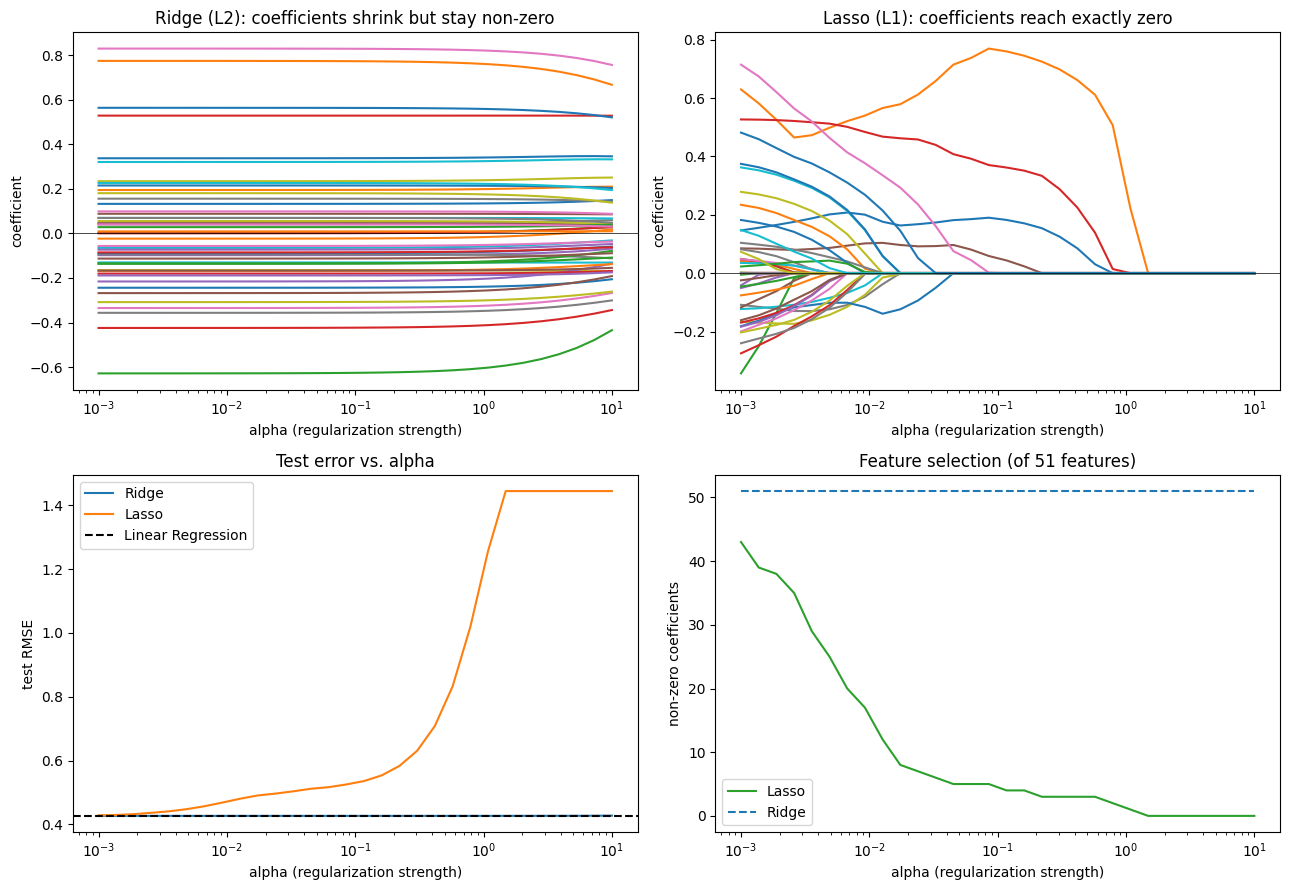

In [142]:
alphas = np.logspace(-3, 1, 30)
ridge_c, lasso_c, ridge_rmse, lasso_rmse = [], [], [], []

for a in alphas:
    r = Ridge(alpha=a).fit(Xtr, yr_train)
    l = Lasso(alpha=a, max_iter=20000).fit(Xtr, yr_train)
    ridge_c.append(r.coef_)
    lasso_c.append(l.coef_)
    ridge_rmse.append(np.sqrt(mean_squared_error(yr_test, r.predict(Xte))))
    lasso_rmse.append(np.sqrt(mean_squared_error(yr_test, l.predict(Xte))))

ridge_c, lasso_c = np.array(ridge_c), np.array(lasso_c)

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0, 0].plot(alphas, ridge_c)
ax[0, 0].set_title("Ridge (L2): coefficients shrink but stay non-zero")
ax[0, 1].plot(alphas, lasso_c)
ax[0, 1].set_title("Lasso (L1): coefficients reach exactly zero")
for a_ in ax[0]:
    a_.axhline(0, color="black", linewidth=0.5)
    a_.set_ylabel("coefficient")

ax[1, 0].plot(alphas, ridge_rmse, label="Ridge")
ax[1, 0].plot(alphas, lasso_rmse, label="Lasso")
ax[1, 0].axhline(np.sqrt(mean_squared_error(yr_test, ols.predict(Xte))),
                 color="black", linestyle="--", label="Linear Regression")
ax[1, 0].set_ylabel("test RMSE")
ax[1, 0].set_title("Test error vs. alpha")
ax[1, 0].legend()

ax[1, 1].plot(alphas, (lasso_c != 0).sum(axis=1), color="tab:green", label="Lasso")
ax[1, 1].plot(alphas, (np.abs(ridge_c) > 1e-8).sum(axis=1), color="tab:blue", linestyle="--", label="Ridge")
ax[1, 1].set_ylabel("non-zero coefficients")
ax[1, 1].set_title(f"Feature selection (of {len(feat_names)} features)")
ax[1, 1].legend()

for a_ in ax.ravel():
    a_.set_xscale("log")
    a_.set_xlabel("alpha (regularization strength)")
plt.tight_layout()
plt.show()

In [143]:
rows = []
for a in [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10]:
    for name, model in [("Ridge", Ridge(alpha=a)), ("Lasso", Lasso(alpha=a, max_iter=20000))]:
        model.fit(Xtr, yr_train)
        c = model.coef_
        rows.append({"model": name, "alpha": a,
                     "test_R2": round(r2_score(yr_test, model.predict(Xte)), 4),
                     "sum_abs_coef": round(np.abs(c).sum(), 3),
                     "zero_coefs": int((c == 0).sum()),
                     "non_zero": int((c != 0).sum())})

pd.DataFrame(rows)

,model,alpha,test_R2,sum_abs_coef,zero_coefs,non_zero
0,Ridge,0.001,0.9126,10.045,0,51
1,Lasso,0.001,0.9119,7.386,8,43
2,Ridge,0.010,0.9126,10.043,0,51
3,Lasso,0.010,0.8934,2.551,37,14
4,Ridge,0.050,0.9126,10.037,0,51
5,Lasso,0.050,0.8736,1.466,46,5
6,Ridge,0.100,0.9126,10.028,0,51
7,Lasso,0.100,0.8651,1.371,47,4
8,Ridge,0.500,0.9125,9.960,0,51
9,Lasso,0.500,0.7137,0.871,48,3


In [144]:
coef_table = pd.DataFrame({"OLS": ols.coef_,
                           "Ridge": ridge_cv.coef_,
                           "Lasso": lasso_cv.coef_}, index=feat_names)

print(f"Ridge alpha = {ridge_cv.alpha_:.3g} | Lasso alpha = {lasso_cv.alpha_:.3g}")
print("Sum of |coefficients|:")
print(coef_table.abs().sum().round(3), "\n")

print("Lasso kept %d of %d features" % ((coef_table["Lasso"] != 0).sum(), len(coef_table)))
print("\nLargest coefficients (by Lasso magnitude):")
print(coef_table.reindex(coef_table["Lasso"].abs().sort_values(ascending=False).index).head(10).round(3))

print("\nZeroed out by Lasso:")
print(list(coef_table.index[coef_table["Lasso"] == 0]))

strong = Lasso(alpha=0.2, max_iter=20000).fit(Xtr, yr_train)
survivors = pd.Series(strong.coef_, index=feat_names)
print("\nSurvivors at alpha = 0.2:")
print(survivors[survivors != 0].sort_values(key=abs, ascending=False).round(3))

Ridge alpha = 1.89 | Lasso alpha = 0.0001
Sum of |coefficients|:
OLS      10.045
Ridge     9.742
Lasso     9.622
dtype: float64 

Lasso kept 50 of 51 features

Largest coefficients (by Lasso magnitude):
                      OLS  Ridge  Lasso
num__PT08.S4(NO2)   0.831  0.815  0.820
num__C6H6(GT)       0.775  0.751  0.761
num__PT08.S2(NMHC) -0.629 -0.584 -0.601
cat__month_12       0.565  0.555  0.554
num__NOx(GT)        0.530  0.530  0.529
cat__hour_3        -0.424 -0.403 -0.397
cat__hour_20        0.338  0.343  0.355
cat__hour_19        0.321  0.327  0.339
cat__hour_7        -0.357 -0.341 -0.332
cat__hour_6        -0.335 -0.317 -0.309

Zeroed out by Lasso:
['cat__hour_1']

Survivors at alpha = 0.2:
num__C6H6(GT)       0.732
num__NOx(GT)        0.342
num__PT08.S1(CO)    0.160
num__NO2(GT)        0.005
dtype: float64


### Task 8: Provide a final documentation cell or appendix section containing a screenshot or export of your Google Cloud billing or resource utilization dashboard showing active credit consumption.





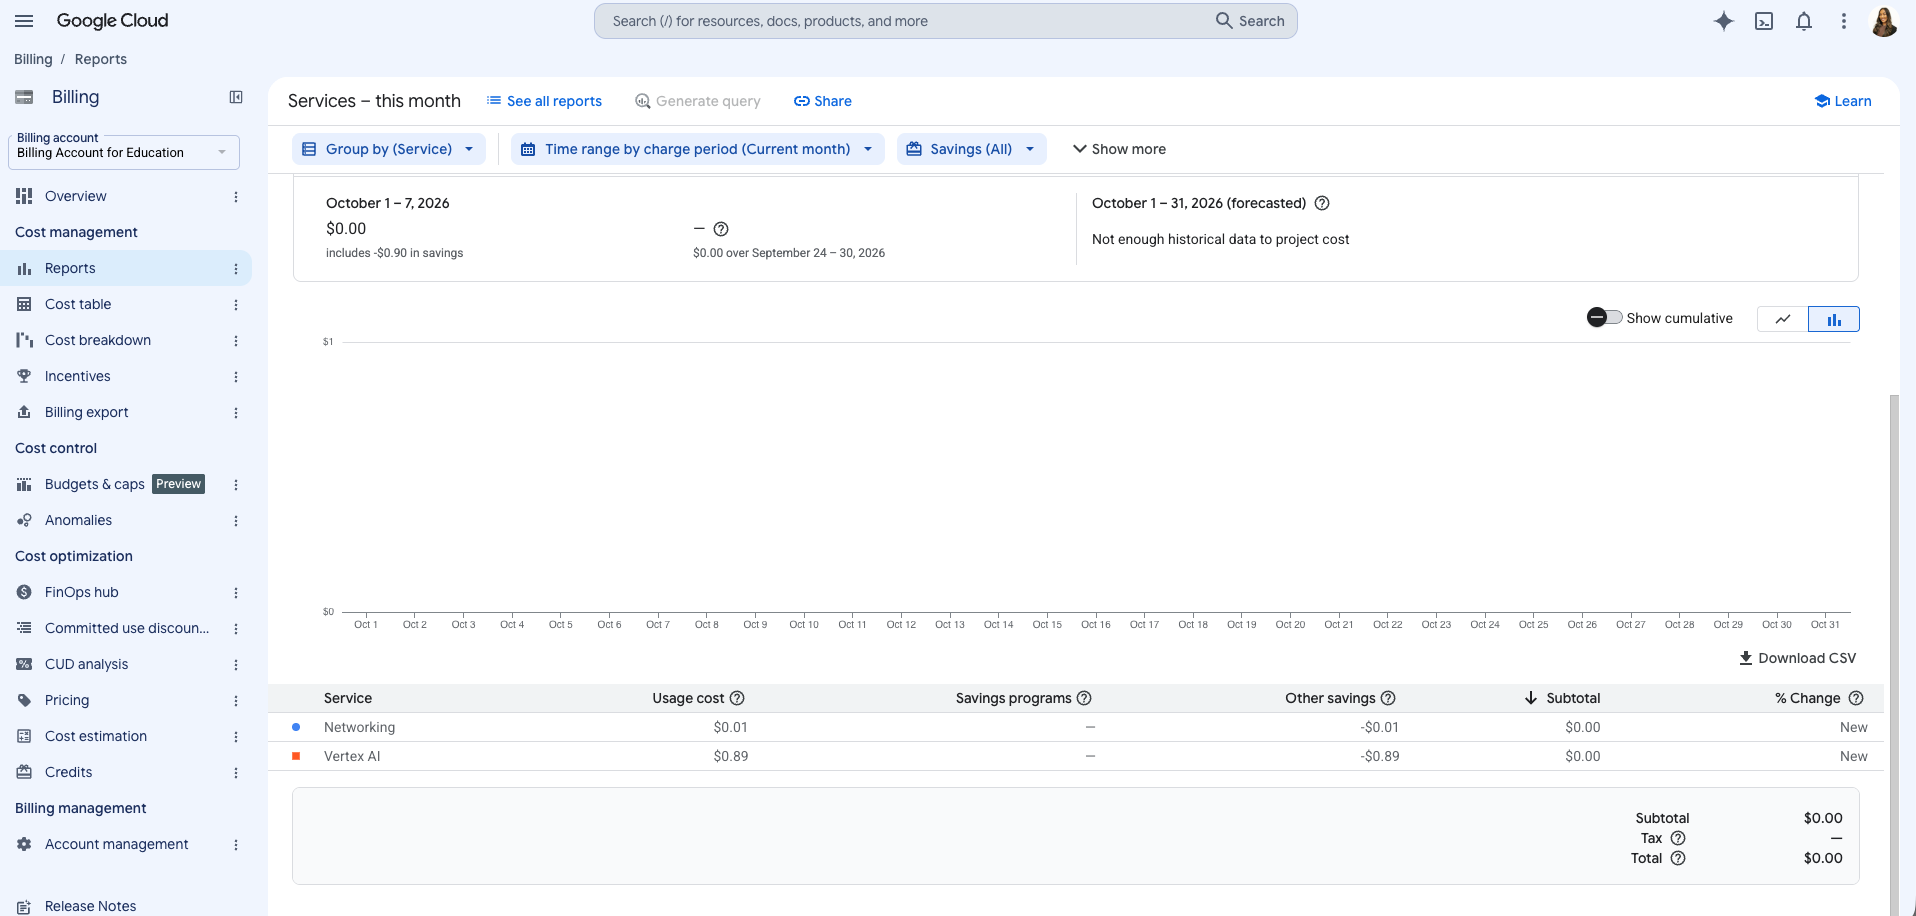

#### StandardScaler vs. MinMaxScaler (for Analysis Q4)

In [145]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np, pandas as pd, time

rows = []
for sname, sc in [("StandardScaler", StandardScaler()), ("MinMaxScaler", MinMaxScaler())]:
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", sc)]), num_feats),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
         categorical_features),
    ])
    A, B = pre.fit_transform(X_train), pre.transform(X_test)

    for mname, m in [
        ("Softmax", LogisticRegression(max_iter=1000, random_state=42)),
        ("SGD log_loss eta0=0.01", SGDClassifier(loss="log_loss", learning_rate="constant",
                                                 eta0=0.01, alpha=1e-4, max_iter=1000,
                                                 tol=1e-3, random_state=42)),
        ("SGD log_loss optimal lr", SGDClassifier(loss="log_loss", learning_rate="optimal",
                                                  alpha=1e-4, max_iter=1000,
                                                  tol=1e-3, random_state=42)),
    ]:
        start = time.perf_counter()
        m.fit(A, y_train)
        elapsed = time.perf_counter() - start
        p = m.predict(B)
        rows.append({"scaler": sname, "model": mname,
                     "iterations": int(np.max(m.n_iter_)),
                     "fit_time_s": round(elapsed, 4),
                     "accuracy": round(accuracy_score(y_test, p), 4),
                     "macro_F1": round(f1_score(y_test, p, average="macro"), 4)})

pd.DataFrame(rows)

,scaler,model,iterations,fit_time_s,accuracy,macro_F1
0,StandardScaler,Softmax,77,1.6542,0.8723,0.8731
1,StandardScaler,SGD log_loss eta0=0.01,46,0.2382,0.8619,0.8627
2,StandardScaler,SGD log_loss optimal lr,46,0.2670,0.8502,0.8522
3,MinMaxScaler,Softmax,67,1.2173,0.8515,0.8527
4,MinMaxScaler,SGD log_loss eta0=0.01,29,0.2976,0.8235,0.8223
5,MinMaxScaler,SGD log_loss optimal lr,43,0.2714,0.8410,0.8403
